In [1]:
from pathlib import Path
REPO_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "absorption_paper_source_data").is_dir())
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.legend_handler import HandlerLine2D  # <-- tight marker-only handles
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial"
plt.rcParams["mathtext.it"] = "Arial:italic"
plt.rcParams["mathtext.bf"] = "Arial:bold"


In [2]:
def format_hkl_tex(h, k, l):
    """Return HKL string with proper overbars in TeX math mode."""
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"


In [3]:
def plot_each_hkl_scaled_paged(csv_no_abs, csv_abs, csv_required, max_per_page=16, ncols=4):

    rows = []  # NEW

    plt.rcParams.update({
        'font.size': 40,
        'axes.titlesize': 34,
        'axes.labelsize': 34,
        'xtick.labelsize': 27,
        'ytick.labelsize': 27,
        'legend.fontsize': 26,
        'legend.title_fontsize': 26
    })

    df_no_abs = pd.read_csv(csv_no_abs).sort_values(["h","k","l","tilt_angle"]).reset_index(drop=True)
    df_abs    = pd.read_csv(csv_abs   ).sort_values(["h","k","l","tilt_angle"]).reset_index(drop=True)
    df_req    = pd.read_csv(csv_required)

    def parse_hkl(s):
        h,k,l = s.split()
        return int(h),int(k),int(l)

    hkls_required = {parse_hkl(s) for s in df_req["HKL"]}

    atten_scale = np.exp(200.0 / 88.4)
    df_abs["intensity"] *= atten_scale

    

    global_max = df_no_abs["intensity"].max()
    df_no_abs["intensity_norm"] = df_no_abs["intensity"] / global_max
    df_abs["intensity_norm"]    = df_abs["intensity"]    / global_max

    hkls_final = list(
        set(zip(df_no_abs.h,df_no_abs.k,df_no_abs.l))
        & set(zip(df_abs.h,df_abs.k,df_abs.l))
        & hkls_required
    )

    hkl_intensity = {}
    for h,k,l in hkls_final:
        sel = (df_no_abs.h==h)&(df_no_abs.k==k)&(df_no_abs.l==l)
        hkl_intensity[(h,k,l)] = df_no_abs.loc[sel,"intensity_norm"].sum()

    hkls_sorted = sorted(hkl_intensity, key=hkl_intensity.get, reverse=True)

    ncols = max(1,int(ncols))
    for page_start in range(0,len(hkls_sorted),max_per_page):
        page_hkls = hkls_sorted[page_start:page_start+max_per_page]
        nrows = math.ceil(len(page_hkls)/ncols)
        fig,axes = plt.subplots(nrows,ncols,figsize=(5*ncols,7*nrows),squeeze=False)

        from matplotlib.lines import Line2D
        fig.legend(
            handles=[
                Line2D([0],[0], color="blue", linestyle="-", linewidth=2),
                Line2D([0],[0], color="red",   linestyle="-", linewidth=2),
            ],
            labels=[
                r"$I_{\mathrm{no-abs}}$",
                r"$I_{\mathrm{abs}}$"
            ],
            loc="upper center",
            ncol=2,
            fontsize=35,
            frameon=False,
            bbox_to_anchor=(0.5, 1.04)
        )
        
        





        for idx,(h,k,l) in enumerate(page_hkls):
            ax = axes[idx//ncols][idx%ncols]

            sel_no = (df_no_abs.h==h)&(df_no_abs.k==k)&(df_no_abs.l==l)
            sel_ab = (df_abs.h==h)&(df_abs.k==k)&(df_abs.l==l)

            x_no = df_no_abs.loc[sel_no,"tilt_angle"].to_numpy()
            y_no = df_no_abs.loc[sel_no,"intensity_norm"].to_numpy()
            x_ab = df_abs.loc[sel_ab,"tilt_angle"].to_numpy()
            y_ab = df_abs.loc[sel_ab,"intensity_norm"].to_numpy()

            if not np.allclose(x_no,x_ab):
                y_ab = np.interp(x_no,x_ab,y_ab)

            I0 = float(y_no.sum())
            I1 = float(y_ab.sum())
            dI = 100*(I0-I1)/I0 if I0>0 else 0.0

            rows.append(dict(h=h,k=k,l=l,
                             I_no_abs=I0,
                             I_abs=I1,
                             delta_pct=dI))  # NEW

            ax.plot(x_no,y_no,"o-",color="blue",markersize=3,linewidth=1.8,alpha=0.9)
            ax.plot(x_no,y_ab,"o-",color="red",markersize=3,linewidth=1.8,alpha=0.5)
            ax.set_xlim(-1,1)
            ax.set_title(format_hkl_tex(h,k,l),fontsize=35)
            

            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))


            ax.legend(
                [],
                title=rf"$\Delta$I $= {dI:.1f}\%$",
                loc="best",
                frameon=True,
                title_fontsize=23
            )






        plt.tight_layout()
            # ---- CENTER LAST ROW IF PARTIALLY FILLED ----
        n_plots = len(page_hkls)
        full_rows = n_plots // ncols
        last_row_count = n_plots % ncols

        if last_row_count != 0:
            row = full_rows  # index of last row
            axes_row = axes[row]

            # get positions of a normal full row
            ref_pos = axes[0][0].get_position()
            width = ref_pos.width
            height = ref_pos.height
            x0 = ref_pos.x0
            x1 = axes[0][-1].get_position().x1
            total_width = x1 - x0

            # total width occupied by existing axes in last row
            used_width = last_row_count * width
            offset = (total_width - used_width) / 2.0

            for j in range(last_row_count):
                pos = axes_row[j].get_position()
                axes_row[j].set_position([
                    x0 + offset + j * width,
                    pos.y0,
                    width,
                    height
                ])

            # hide unused axes
            for j in range(last_row_count, ncols):
                axes_row[j].set_visible(False)

        plt.show()

    df_out = pd.DataFrame(rows)
    with pd.option_context("display.float_format","{:.3f}".format):
        print(df_out)
    return df_out


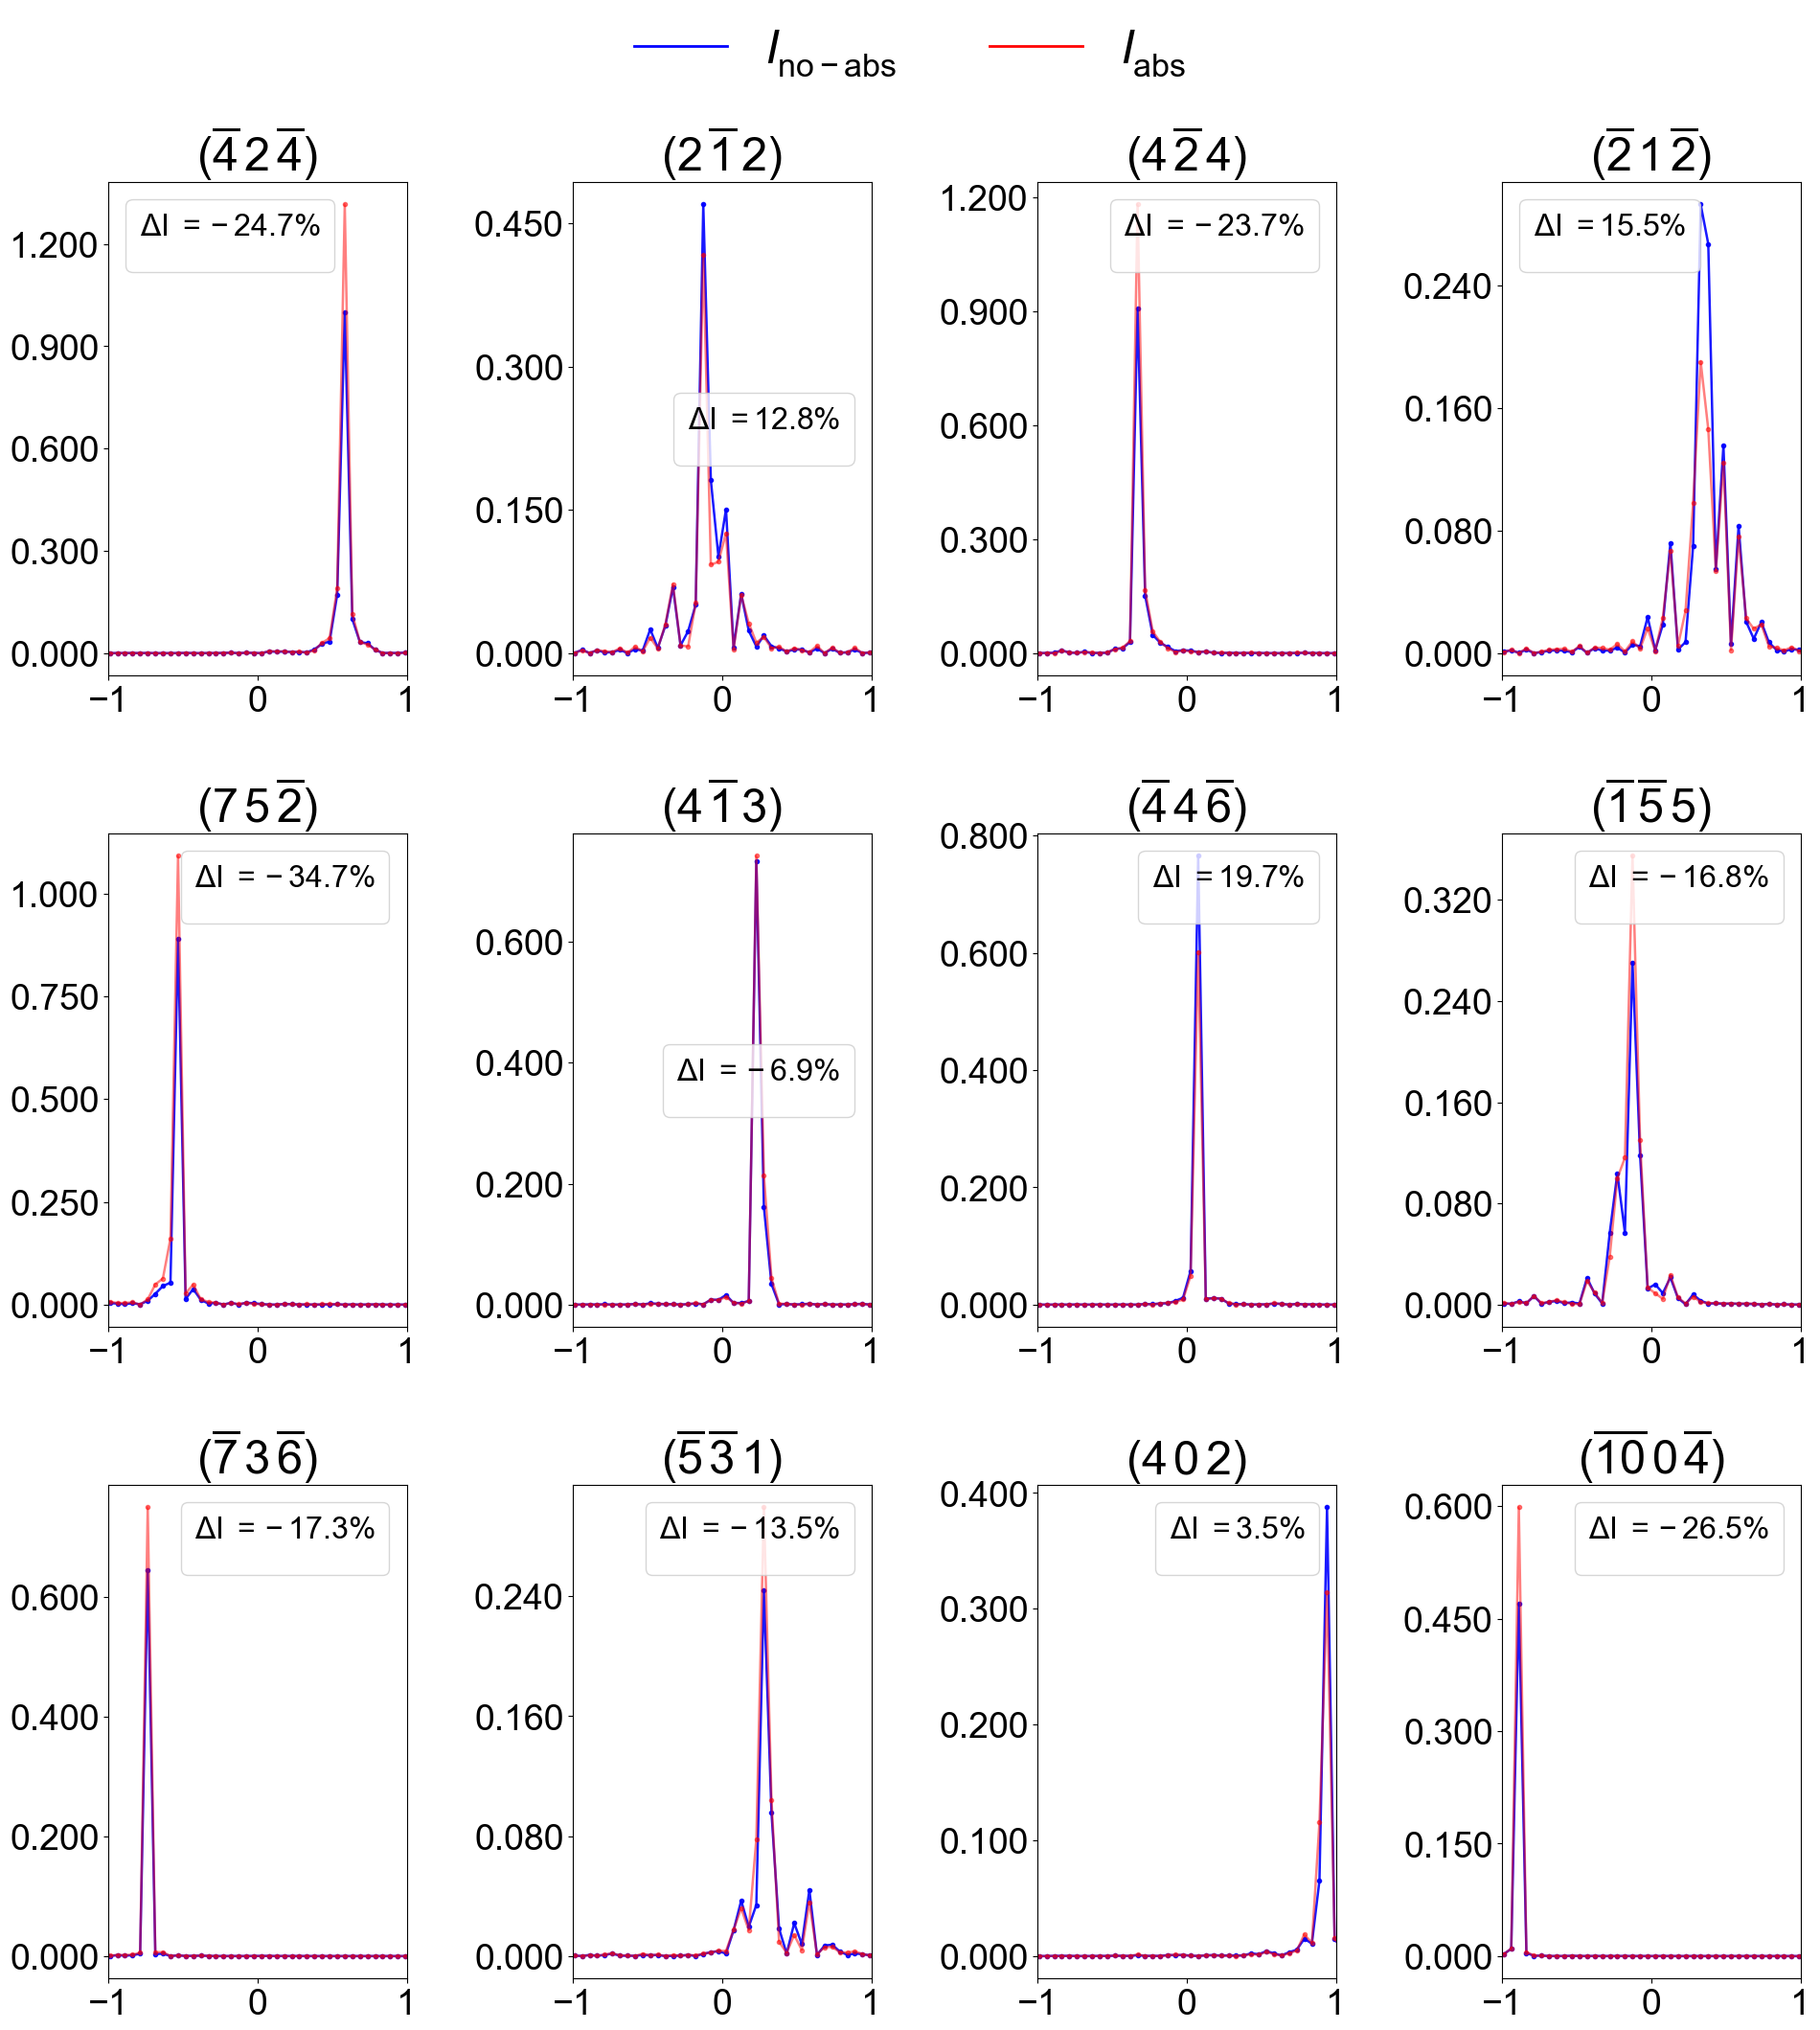

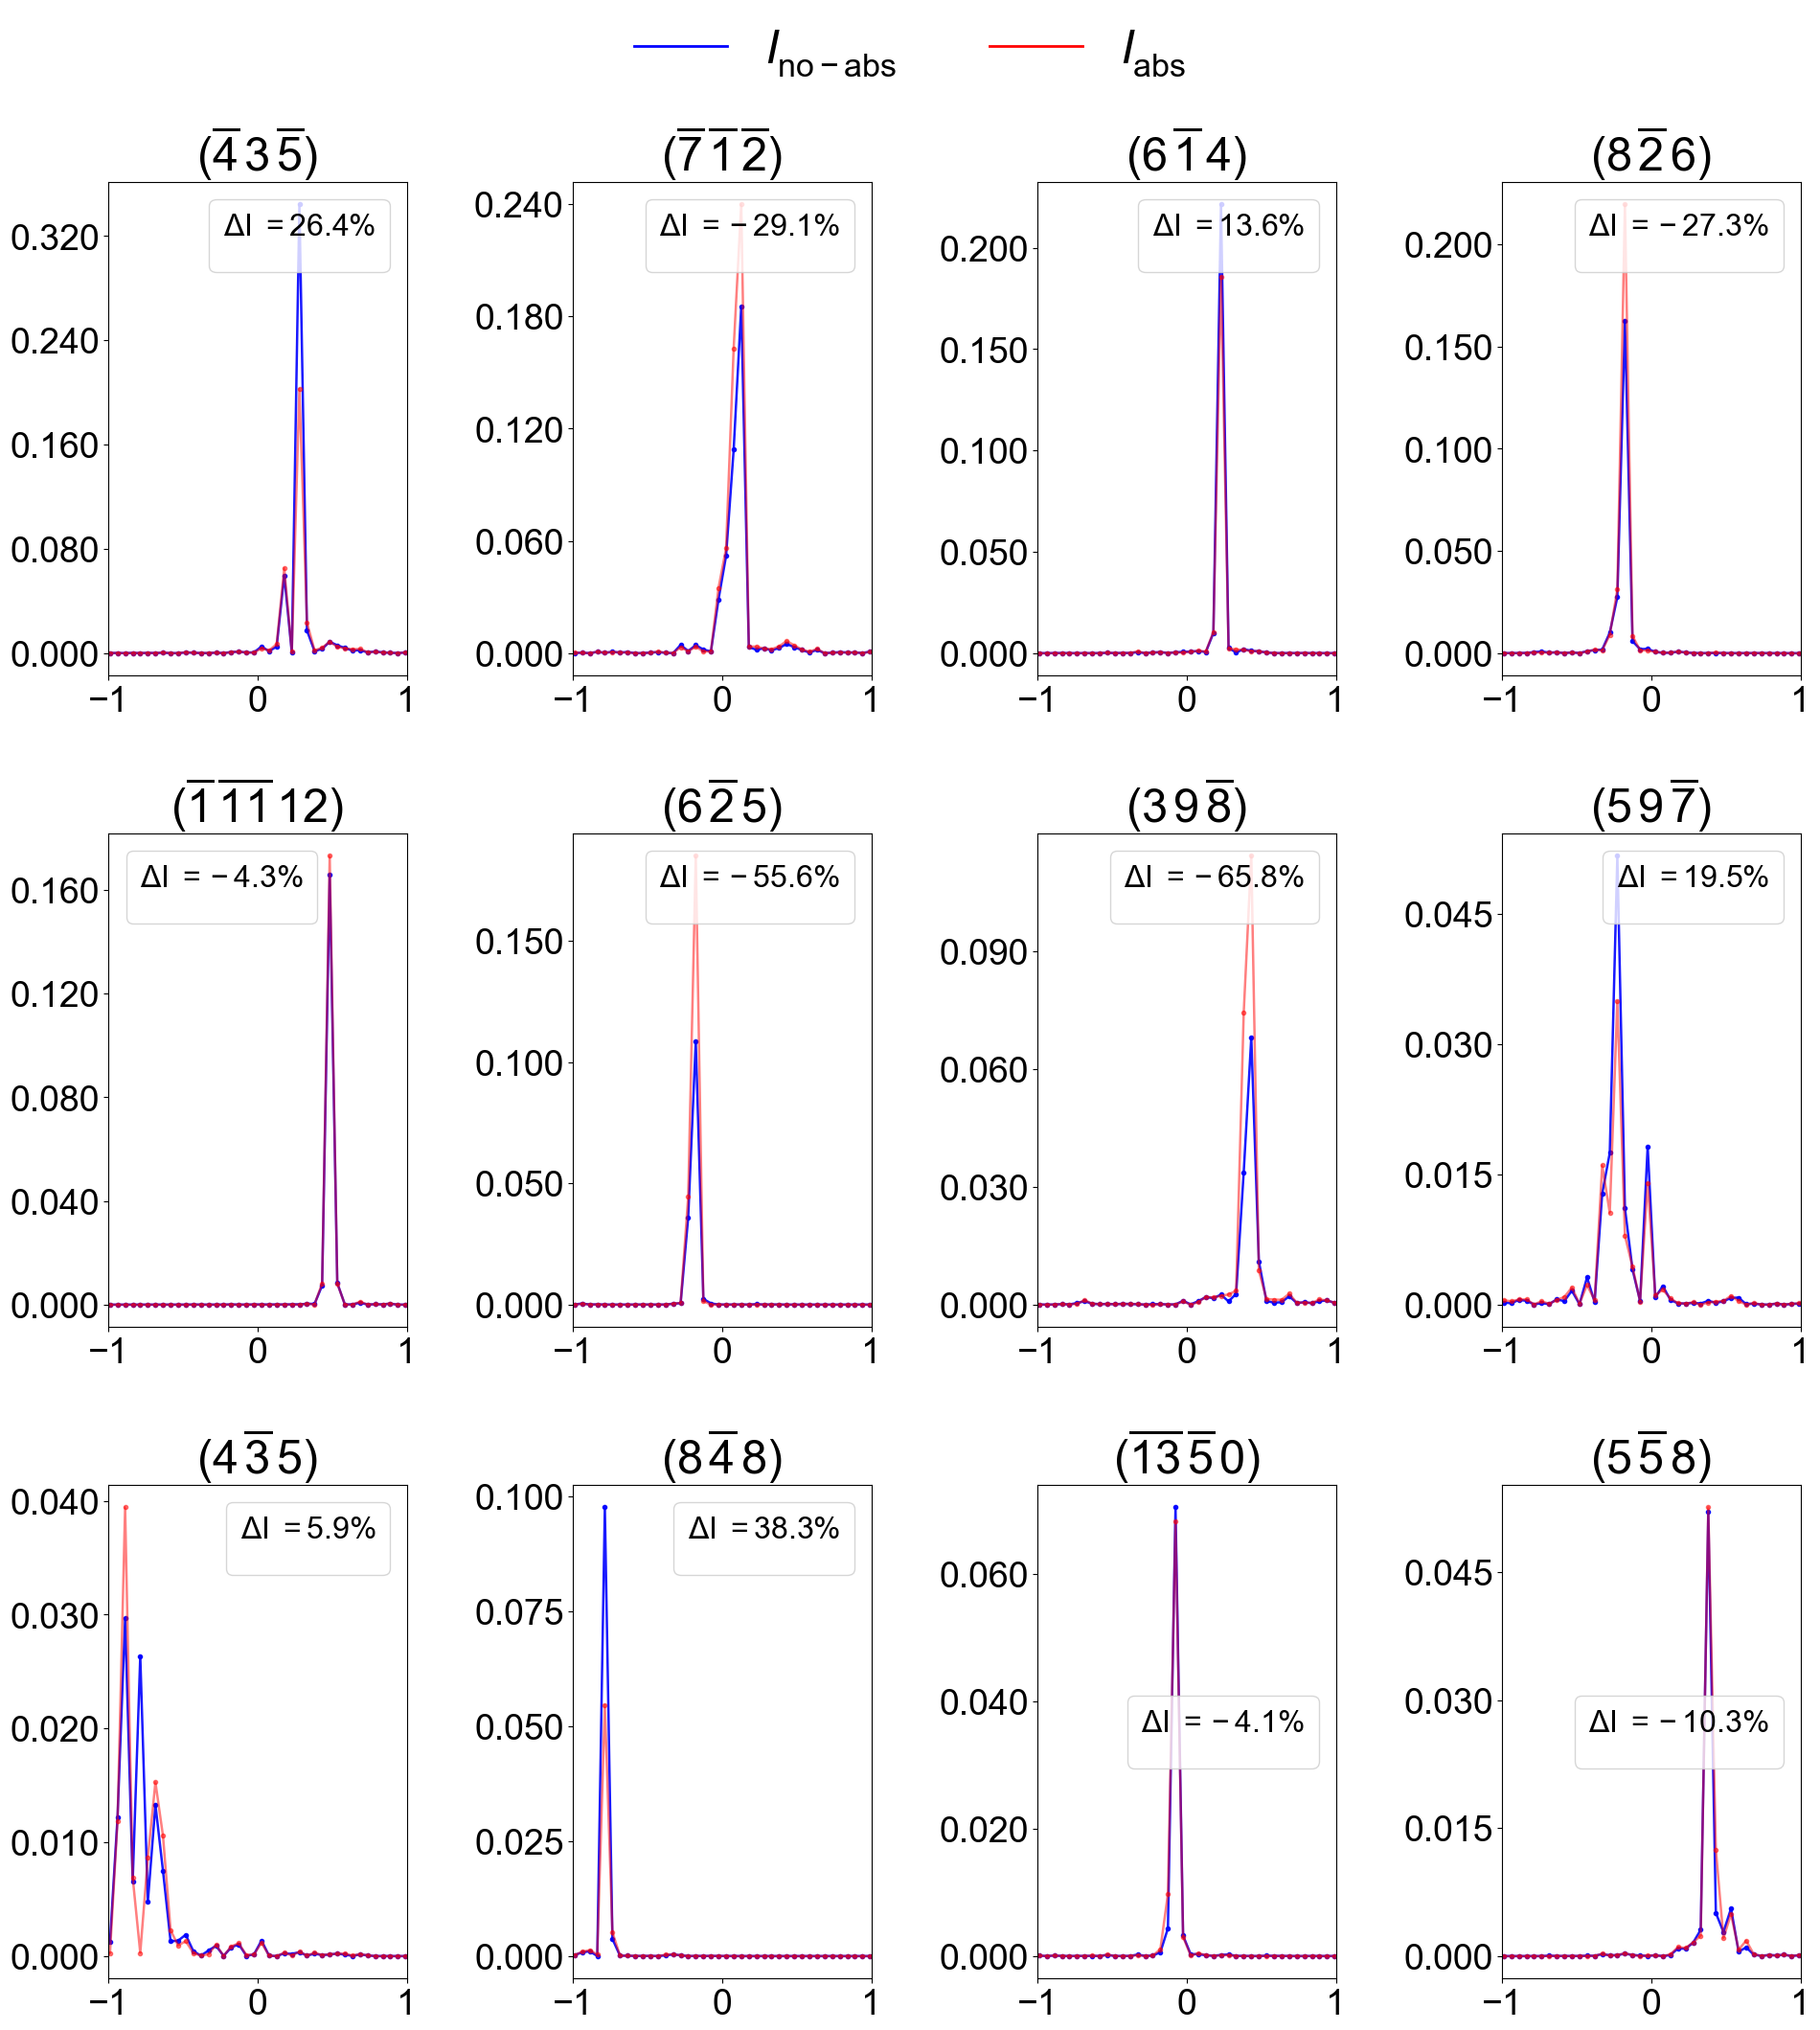

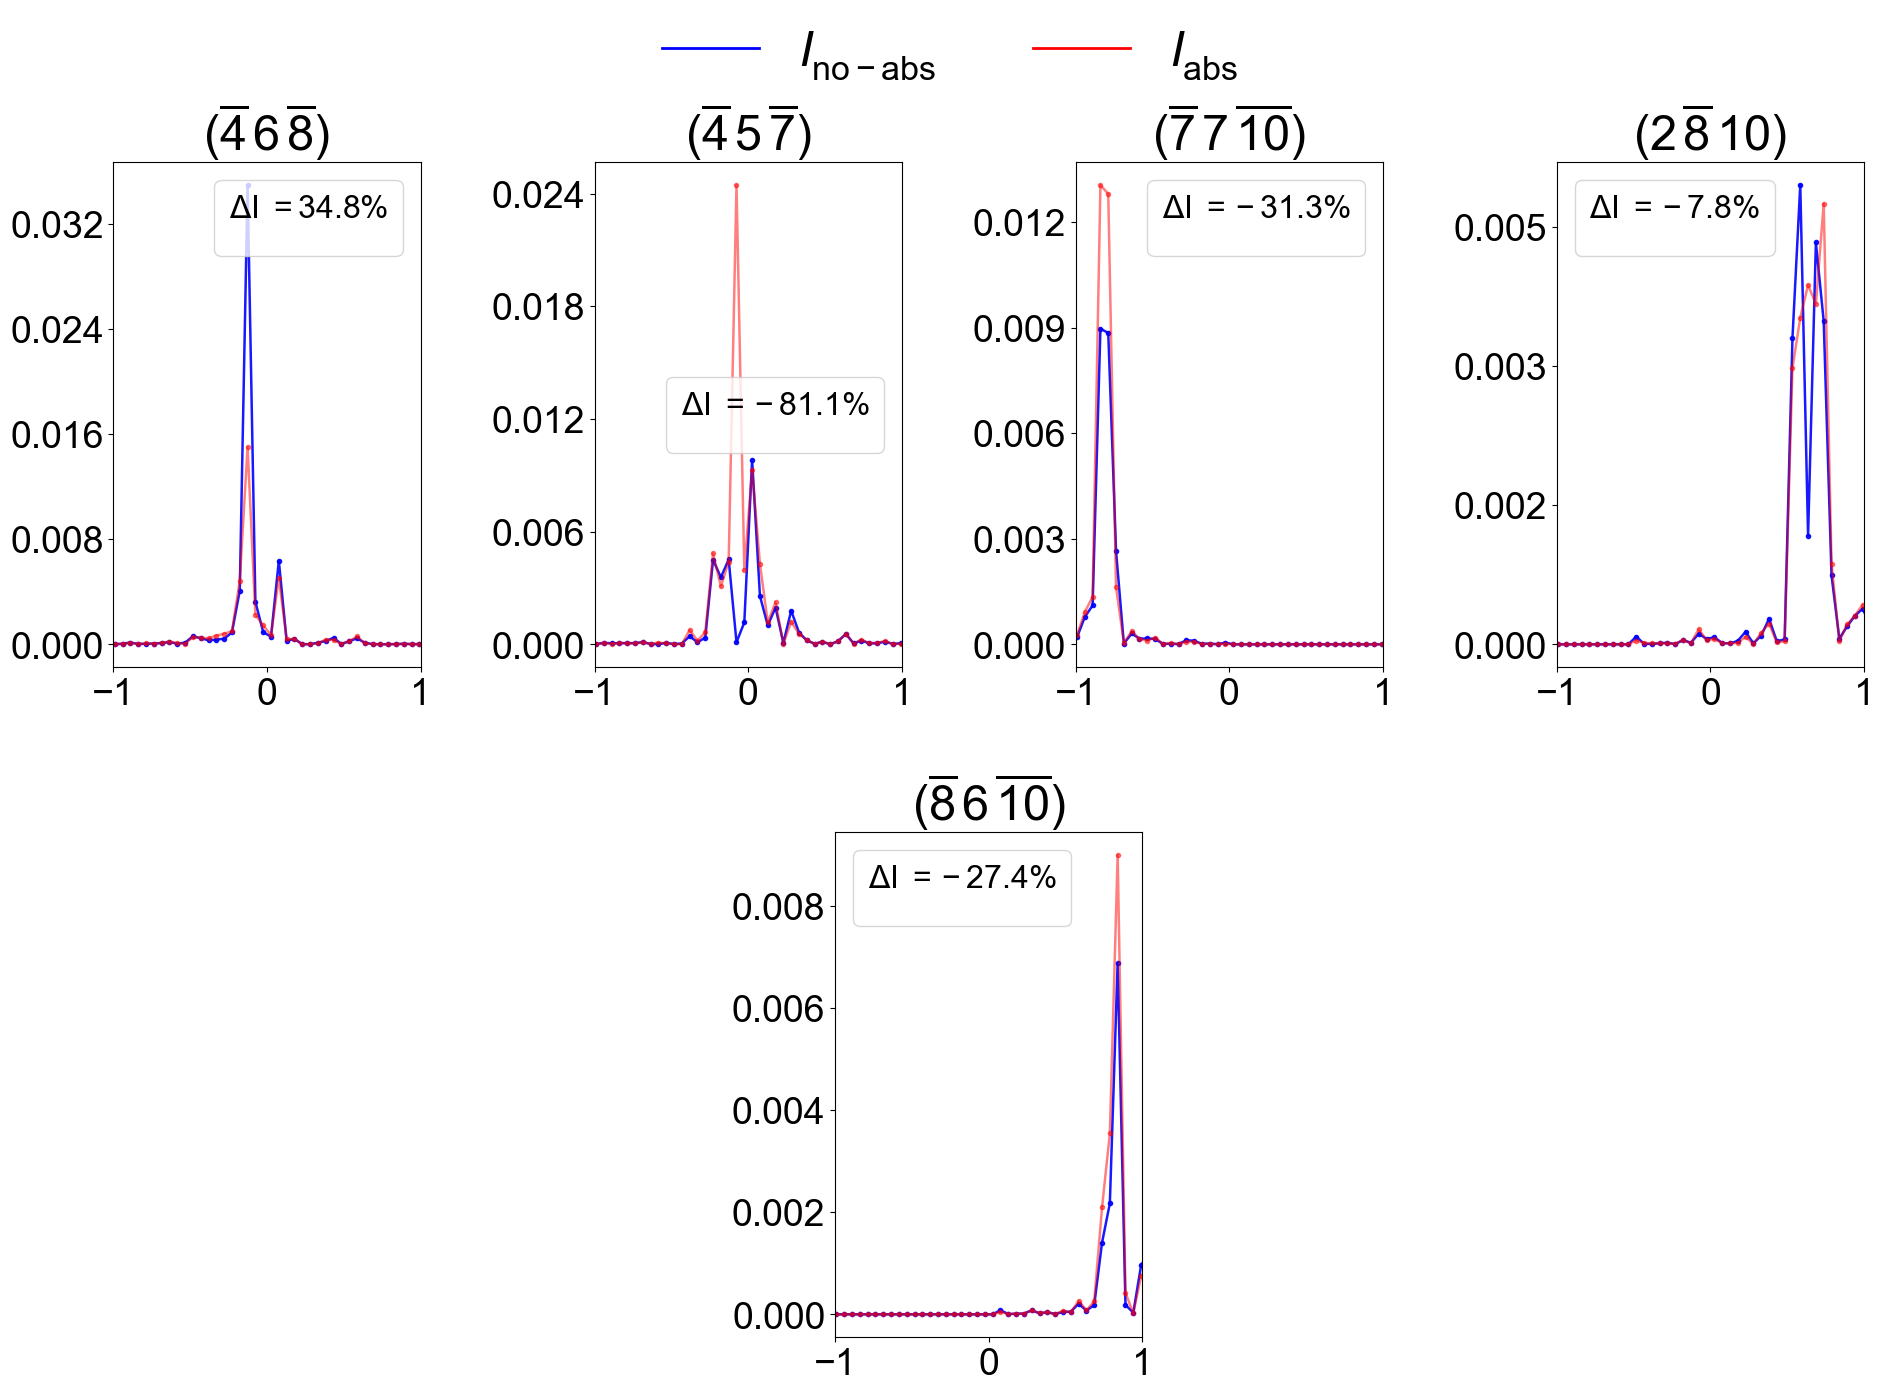

     h   k   l  I_no_abs  I_abs  delta_pct
0   -4   2  -4     1.466  1.827    -24.668
1    2  -1   2     1.308  1.140     12.818
2    4  -2   4     1.263  1.562    -23.657
3   -2   1  -2     1.160  0.980     15.504
4    7   5  -2     1.144  1.540    -34.658
5    4  -1   3     0.993  1.061     -6.852
6   -4   4  -6     0.892  0.716     19.661
7   -1  -5   5     0.750  0.875    -16.784
8   -7   3  -6     0.666  0.781    -17.316
9   -5  -3   1     0.588  0.668    -13.547
10   4   0   2     0.560  0.541      3.457
11 -10   0  -4     0.494  0.625    -26.498
12  -4   3  -5     0.474  0.349     26.412
13  -7  -1  -2     0.423  0.546    -29.142
14   6  -1   4     0.246  0.213     13.561
15   8  -2   6     0.220  0.280    -27.276
16  -1 -11  12     0.185  0.193     -4.320
17   6  -2   5     0.150  0.234    -55.558
18   3   9  -8     0.137  0.228    -65.792
19   5   9  -7     0.135  0.109     19.472
20   4  -3   5     0.124  0.116      5.892
21   8  -4   8     0.106  0.065     38.267
22 -13  -5 

,h,k,l,I_no_abs,I_abs,delta_pct
0,-4,2,-4,1.465656,1.827201,-24.667724
1,2,-1,2,1.307988,1.140324,12.818475
2,4,-2,4,1.262876,1.561632,-23.656855
3,-2,1,-2,1.159690,0.979890,15.504152
4,7,5,-2,1.143856,1.540295,-34.658131
5,4,-1,3,0.993321,1.061382,-6.851945
6,-4,4,-6,0.891585,0.716287,19.661357
7,-1,-5,5,0.749629,0.875445,-16.783738
8,-7,3,-6,0.665717,0.780992,-17.315953
9,-5,-3,1,0.588423,0.668136,-13.546873


In [8]:
plot_each_hkl_scaled_paged(
    csv_no_abs=str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/no_abs_rotation_1_thickness_2001_rocking_curves.csv"),
    csv_abs=str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/param_rotation_1_thickness_2001_rocking_curves.csv"),
    csv_required=str(REPO_ROOT / "absorption_paper_source_data/two_beam/allowed_hkls.csv"),
    max_per_page=12,
    ncols=4
)
